In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [2]:
cwd = Path.cwd()
PARQUET_PATH = cwd.parent / "datasets" / "htem_neural_net_dataset.parquet"

In [3]:
df_raw = pd.read_parquet(PARQUET_PATH)
df_raw.head(5)

,sample_id,library_id,thickness,deposition_sample_time_min,deposition_base_pressure_mtorr,deposition_growth_pressure_mtorr,deposition_initial_temp_c,deposition_compound_Co_power,deposition_compound_CoO_power,deposition_compound_Cr_power,...,xrd_background_5180,xrd_intensity_5180,xrd_background_5185,xrd_intensity_5185,xrd_background_5190,xrd_intensity_5190,xrd_background_5195,xrd_intensity_5195,xrd_background_5200,xrd_intensity_5200
0,322800,10104,0.2843,60,0.006,10.0,310,0,0,0,...,3135.0,3288.0,3132.0,3235.0,3157.0,3162.0,3117.0,3089.0,3100.0,3100.0
1,322802,10104,0.2942,60,0.006,10.0,310,0,0,0,...,3078.0,3060.0,3087.0,3064.0,3058.0,3131.0,3031.0,2937.0,3025.0,3025.0
2,322801,10104,0.3090,60,0.006,10.0,310,0,0,0,...,3161.0,3161.0,3138.0,3194.0,3114.0,3084.0,3092.0,3055.0,3137.0,3137.0
3,322804,10104,0.3259,60,0.006,10.0,310,0,0,0,...,3276.0,3314.0,3274.0,3290.0,3263.0,3231.0,3265.0,3301.0,3211.0,3211.0
4,322803,10104,0.3396,60,0.006,10.0,310,0,0,0,...,3227.0,3246.0,3214.0,3292.0,3201.0,3223.0,3175.0,3132.0,3169.0,3169.0


In [4]:
X = df_raw.iloc[:, 3:]
y = df_raw["thickness"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
lr = linear_model.LinearRegression(positive=True)
lr.fit(X_train, y_train)

LinearRegression(positive=True)

In [7]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [8]:
import matplotlib.pyplot as plt

In [9]:
def plot_scatter_with_fit(ax, x, y, title="", xlabel="", ylabel=""):
    x = np.asarray(x)
    y = np.asarray(y)

    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(min(x.min(), y.min()), max(x.max(), y.max()), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # Ideal line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.7, label="ideal: y=x")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.legend()

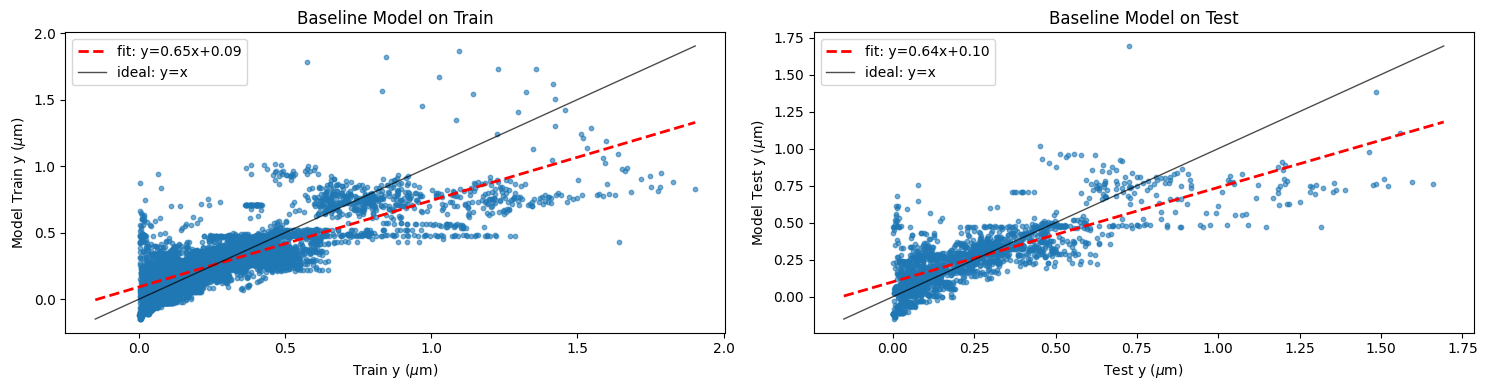

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

plot_scatter_with_fit(
    axes[0],
    y_train,
    y_train_pred,
    title="Baseline Model on Train",
    xlabel=r"Train y ($\mu$m)",
    ylabel=r"Model Train y ($\mu$m)"
)

plot_scatter_with_fit(
    axes[1],
    y_test,
    y_test_pred,
    title="Baseline Model on Test",
    xlabel=r"Test y ($\mu$m)",
    ylabel=r"Model Test y ($\mu$m)"
)

plt.tight_layout()

In [11]:
# From the data above, overfitting is not occuring, however accuracy is poor

# Train metrics
# print(f"Train set R2: {round(r2_score(y_train, y_train_pred), 3)}")
# print(f"Train set MSE: {round(mean_squared_error(y_train, y_train_pred), 3)}")
# print(f"Train set RMSE: {round(root_mean_squared_error(y_train, y_train_pred), 3)*1000}nm \n")

# Test metrics
print(f"Test set R2: {round(r2_score(y_test, y_test_pred), 3)}")
print(f"Test set MSE: {round(mean_squared_error(y_test, y_test_pred), 3)}")
print(f"Test set RMSE: {round(root_mean_squared_error(y_test, y_test_pred), 3)*1000}nm")

Test set R2: 0.616
Test set MSE: 0.026
Test set RMSE: 161.0nm
